# Data 206 Capstone EDA Project

## Installing libraries

In [ ]:
library(dplyr)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Attaching package: 'lubridate'

The following objects are masked from 'package:base':

    date, intersect, setdiff, union

## Inviting the two data sets

In [ ]:
Impound <- read.csv("C:/Users/casti/OneDrive/Documents/Data 206 Capstone Project/.quarto/project-cache/Animal Impound.csv")
Shelter <- read.csv("C:/Users/casti/OneDrive/Documents/Data 206 Capstone Project/.quarto/project-cache/Animal Pathway.csv") #Adding the two datasets

## Joining the data sets and viewing how many animals IDs linked

In [ ]:
colnames(Impound)[colnames(Impound) == "Animal.identification.number"] <- "Animal.ID"
colnames(Shelter)[colnames(Shelter) == "Animal.identification.number"] <- "Animal.ID" # Changing the name of the column to make it easier
combined <- left_join(Impound,Shelter, by = "Animal.ID") #The merging of the two datasets

Warning in left_join(Impound, Shelter, by = "Animal.ID"): Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 26 of `x` matches multiple rows in `y`.
ℹ Row 21 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.

[1] 5847

 [1] "Impound.number"           "Kennel.number.location"  
 [3] "Animal.ID"                "Animal.source"           
 [5] "Animal.owner"             "jurisdiction"            
 [7] "Impound.type"             "Intake.subcategory"      
 [9] "Impound.date.and.time"    "Release.date"            
[11] "Surrender.reason"         "source"                  
[13] "Total.number.per.impound" "Animal.intake.condition" 
[15] "Animal.control.hold"      "Outcome.type"            
[17] "Outcome.subtype"          "Animal.outcome.condition"
[19] "Departure.date.and.time"  "Animal.name"             
[21] "Animal.type"              "Sex.of.animal"           
[23] "Pet.s.age.in.years"       "Pet.s.age.in.months"     
[25] "Pet.s.date.of.birth"      "Pet.s.age"               
[27] "Bite.history"             "Animal.size"             
[29] "Color.of.animal"          "Breed.of.animal"         
[31] "Collar.present"          

## Changing some column names

In [ ]:
combined <- combined %>%
  rename(
    Age_Year = Pet.s.age.in.years,
    Animal_Type = Animal.type,
    Bite_History = Bite.history,
    Color = Color.of.animal,
    Breed = Breed.of.animal
  )

  

## My first attempt to create datetime variables for future analysis

In [ ]:
combined <- combined %>%
  mutate(
    Departure = mdy_hm(Departure.date.and.time),
    Intake = mdy_hm(Impound.date.and.time), #Creating new variables for datetime to take the difference.
    LengthOfStay = round(as.numeric(difftime(Departure, Intake, units = "days")), 2)
  )

  

## Creating a day hour and minute variable for how long the animals have been in the shelter

In [ ]:
combined <- combined %>%
  mutate(
    StayDays = floor(LengthOfStay),#Looking at the first number of the decimal for the hour 
    

    StayHours = floor((LengthOfStay - floor(LengthOfStay)) * 24), # Removes the front decimal and looks at the second digit to get hours
    
    StayMinutes = round(((LengthOfStay - floor(LengthOfStay)) * 24 - StayHours) * 60) # Looks at the last digit of the decimal and creates it into minutes
  )

## Creating a year/month dataframe

In [ ]:
Year_month <- combined %>%
  filter(!is.na(Departure.date.and.time)) # Made a new dataframe for Yearmonth due to complications of doing it to combined dataframe and filter for no NAs

Year_month$Departure.date.and.time[Year_month$Departure.date.and.time == ""] <- NA # Getting rid of negative space as some inputs in the row were " " to the word NA
Year_month <- combined %>%
  filter(!is.na(Departure.date.and.time)) # Had to do it twice as the spaces were now turned to NAs
head(Year_month$Departure.date.and.time) # To check for NAs

[1] "2/27/2026 18:58" "2/27/2026 18:31" "2/26/2026 20:53" "2/26/2026 14:43"
[5] ""                "2/26/2026 12:01"

In [ ]:
Year_month$Departure.date.and.time <- as.POSIXct(
 Year_month$Departure.date.and.time,
  format = "%m/%d/%Y %H:%M" # Had to do this again different method to get the format right this time
)
Year_month$YearMonth <- format(Year_month$Departure.date.and.time, "%Y-%m")
# Having year/month as a new variable to be part of my graph below to have a compact x axis

In [ ]:
monthly_outcomes <- Year_month %>%
  filter(!is.na(Departure.date.and.time)) %>% # making sure there is no NAs 
  group_by(YearMonth, Outcome.type.y) %>% # To create a group for each month for each outcome
  summarise(count = n(), .groups = "drop") #To make each outcome a new row for each month

  

# These graphs could possibly supplement my tableau map

## First Graph for Project - Are certain times of the year associated with higher intake rates?​

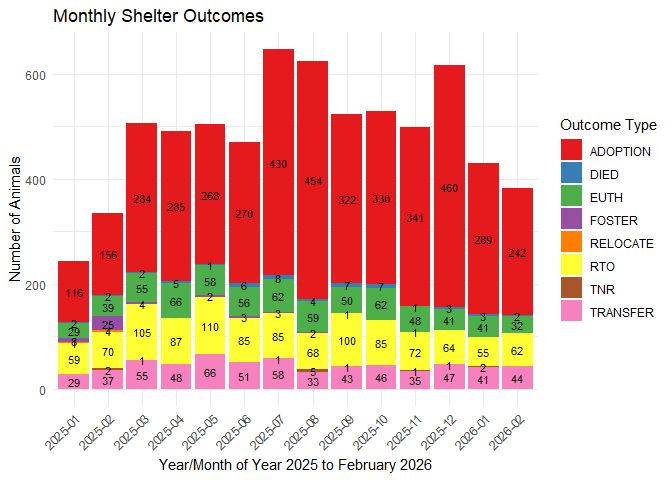

In [ ]:
ggplot(monthly_outcomes, aes(x = YearMonth, y = count, fill = Outcome.type.y)) +
  geom_bar(stat = "identity") + # Make sure that it uses the counts from montly income
  theme_minimal() + # Add theme to my graph
   geom_text(aes(label = count),
            position = position_stack(vjust = 0.5), # This will center my count in the middle of each stack
            size = 3,
            color = "black") +
  scale_fill_brewer(palette = "Set1")  + 
  labs(
    title = "Monthly Shelter Outcomes",
    x = "Year/Month of Year 2025 to February 2026",
    y = "Number of Animals",
    fill = "Outcome Type"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) # This makes it possible so the x labels don't overlap

## Creating second data frame for my next graph

In [ ]:
Euthanized <- combined %>%
  filter(Outcome.type.y == "EUTH") #Filter for Euthanization

Euthanized <- Euthanized %>%
  filter(!is.na(Age_Year)) #Remove any NAs
Euthanized <- Euthanized %>%
  mutate(
    Age_group = case_when(
     Age_Year < 1 ~ "Under 1", # Create age groups as every number will be hard to graph
      Age_Year >= 1 & Age_Year < 3 ~ "1-3 Age group",
      Age_Year >= 3 & Age_Year < 7 ~ "3-7 Age group",
      Age_Year >= 7& Age_Year < 10 ~ "7-10 Age group",
      Age_Year > 10 ~ "10+ Age group"
    )
  )
Euthanized <- Euthanized %>%
  filter(!is.na(Age_group), !is.na(Animal_Type)) # Make sure any Nas are gone

Euthanized$Age_group <- factor(Euthanized$Age_group, levels = c("Under 1","1-3 Age group", "3-7 Age group","7-10 Age group","10+ Age group" )) # To change the order of the levels in which they present in the barchart below

## Second Graph- Does age affect euthanizing likelihood?​

ℹ Please use `after_stat(count)` instead.

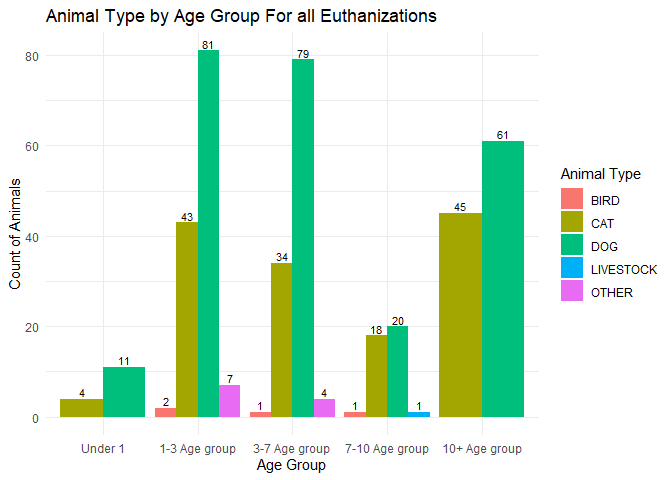

In [ ]:
ggplot(Euthanized, aes(x = Age_group, fill = Animal_Type)) +
  geom_bar(position = "dodge") +
  theme_minimal() +
   geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.9), #Helps align the number in the middle of each bar
    vjust = -0.3, #Helps align the number in the middle of each bar
    size = 3
  ) +
  labs(
    title = "Animal Type by Age Group For all Euthanizations",
    x = "Age Group",
    y = "Count of Animals",
    fill = "Animal Type"
  )

## Creating a new dataframe to get all the animal outcomes in percentage

In [ ]:
summary_data <- combined %>%
  filter(!is.na(Outcome.type.x)) %>%       # remove missing outcomes
  group_by(Outcome.type.x) %>%
  summarise(count = n()) %>%
  mutate(percentage = count / sum(count) * 100)

## Creating the third graph- What percentage of animals are adopted vs. euthanized vs. transferred?​

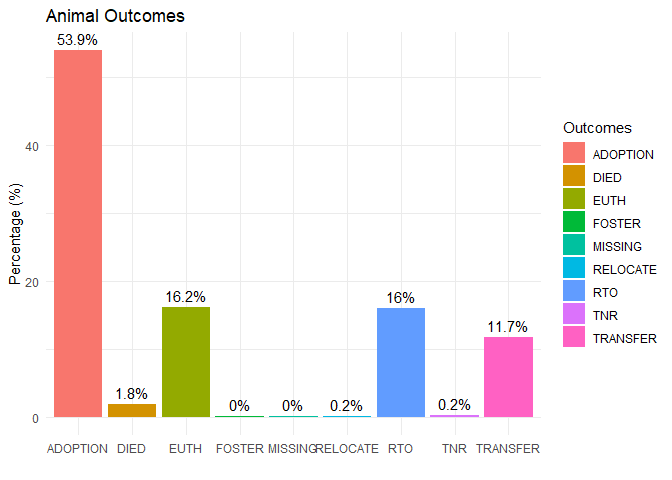

In [ ]:
ggplot(summary_data, aes(x = Outcome.type.x, y = percentage, fill = Outcome.type.x)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(round(percentage,1), "%")), vjust = -0.5) +
  labs(title = "Animal Outcomes", y = "Percentage (%)", x = "", fill = "Outcomes") +
  theme_minimal()

## Creating a dataframe for the different breeds of animals to remove any NAs

In [ ]:
breed_counts <- combined %>%
  filter(!is.na(Breed)) %>%       
  group_by(Breed) %>%
  summarise(count = n()) %>%
  arrange(desc(count))        

## Creating the Fourth Graph- What are the most common breeds of animals entering the shelter system?​

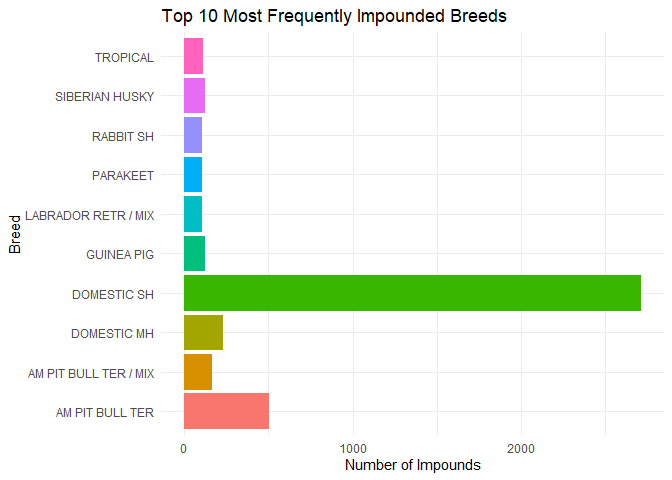

In [ ]:
library(ggplot2)

top_breeds <- breed_counts %>%
  slice_max(count, n = 10)     # pick top 10


ggplot(top_breeds, aes(x = Breed, y = count, fill = Breed)) +
  geom_bar(stat = "identity") +
  coord_flip() +                     
  labs(title = "Top 10 Most Frequently Impounded Breeds",
       x = "Breed",
       y = "Number of Impounds") +
  theme_minimal() +
  theme(legend.position = "none")    # hide legend 

## Just wanted to see the mean number of days that the animals are at the shelter

In [ ]:
mean(combined$StayDays, na.rm = TRUE)

[1] 17.29841

  

## Creating the bite dataframe to remove NAs

In [ ]:
Bite_animal <- combined %>%
  filter(!is.na(Bite_History), Bite_History !="") #Removing NAs and blanks

  
  

## Creating fifth graph- Does the animal bite history affect its outcome?​

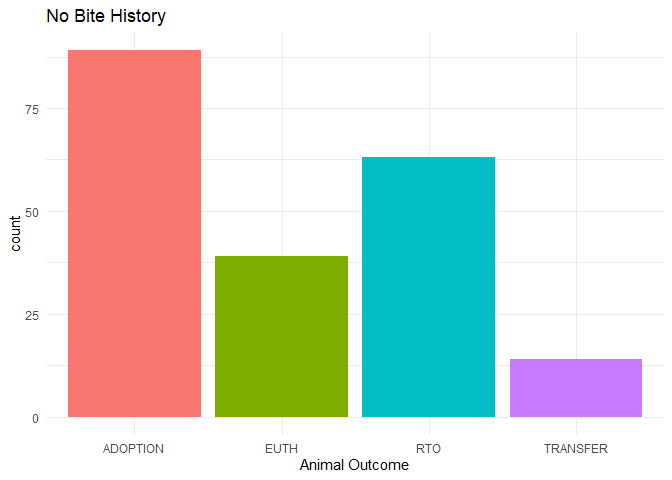

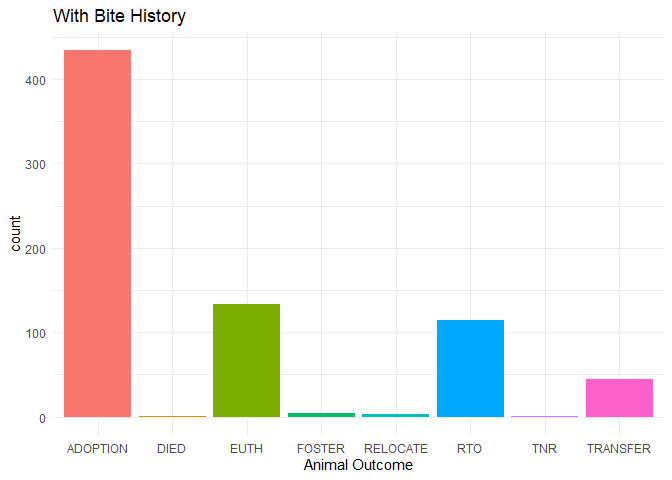

In [ ]:
ggplot(Bite_animal %>% filter(Bite_History == "N"),
                 aes(x = Outcome.type.y, fill = Outcome.type.y)) +
  
  geom_bar() + labs(title = "No Bite History", x = "Animal Outcome") + theme_minimal() + theme(legend.position = "none")

## Creating the Sixth Graph- How long do animals typically stay in the shelter?

ℹ Please use `linewidth` instead.

(`geom_line()`).

(`geom_point()`).

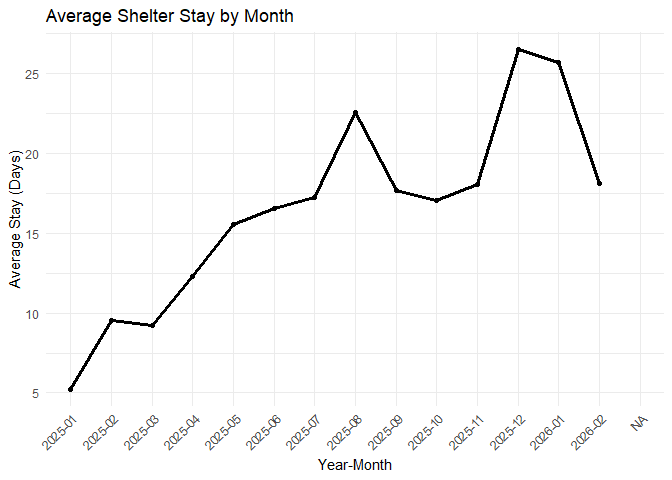

In [ ]:
  Year_month %>%  
  group_by(YearMonth) %>%
  summarise(avg_stay = mean(StayDays, na.rm = TRUE)) %>%
  
  ggplot(aes(x = YearMonth, y = avg_stay, group = 1)) + # Creates a continous line
  geom_line(size = 1.2) +
  geom_point() +
  labs(
    title = "Average Shelter Stay by Month",
    x = "Year-Month",
    y = "Average Stay (Days)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Exploring some statistical analysis:

In [ ]:
lm(StayDays ~ Age_Year + Animal_Type + Outcome.type.y, data = combined)


Call:
lm(formula = StayDays ~ Age_Year + Animal_Type + Outcome.type.y, 
    data = combined)

Coefficients:
           (Intercept)                Age_Year          Animal_TypeCAT  
               6.26172                 0.08304                21.56054  
        Animal_TypeDOG    Animal_TypeLIVESTOCK        Animal_TypeOTHER  
              20.45365                 5.97993                17.27516  
    Outcome.type.yDIED      Outcome.type.yEUTH    Outcome.type.yFOSTER  
             -14.11251               -16.44381               -10.12848  
Outcome.type.yRELOCATE       Outcome.type.yRTO       Outcome.type.yTNR  
             -10.75910               -24.36657               -13.31245  
Outcome.type.yTRANSFER  
             -10.53075  


Call:
lm(formula = StayDays ~ Age_Year + Animal_Type + Outcome.type.y, 
    data = combined)

Residuals:
    Min      1Q  Median      3Q     Max 
-28.154 -16.905  -6.703   1.485 285.620 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)              6.26172    4.19089   1.494 0.135238    
Age_Year                 0.08304    0.13366   0.621 0.534433    
Animal_TypeCAT          21.56054    4.25366   5.069 4.23e-07 ***
Animal_TypeDOG          20.45365    4.26048   4.801 1.65e-06 ***
Animal_TypeLIVESTOCK     5.97993   21.73255   0.275 0.783211    
Animal_TypeOTHER        17.27516    4.65287   3.713 0.000208 ***
Outcome.type.yDIED     -14.11251   10.04299  -1.405 0.160053    
Outcome.type.yEUTH     -16.44381    1.68728  -9.746  < 2e-16 ***
Outcome.type.yFOSTER   -10.12848    7.34597  -1.379 0.168056    
Outcome.type.yRELOCATE -10.75910   15.05518  -0.715 0.474879    
Outcome.type.yRTO      -24.36657    1.48046 -16.459  < 2e-16 ***
Outcome.type.yTNR

In [ ]:
combined$Adopted <- ifelse(combined$Outcome.type.x == "ADOPTION", 1, 0)

glm(Adopted ~ StayDays + Age_Year + Animal_Type + Bite_History,
    data = combined,
    family = "binomial")


Call:  glm(formula = Adopted ~ StayDays + Age_Year + Animal_Type + Bite_History, 
    family = "binomial", data = combined)

Coefficients:
         (Intercept)              StayDays              Age_Year  
             2.73663               0.03118              -0.15811  
      Animal_TypeCAT        Animal_TypeDOG  Animal_TypeLIVESTOCK  
            -1.68876              -2.54482             -13.28869  
    Animal_TypeOTHER         Bite_HistoryN         Bite_HistoryY  
            -1.51100              -0.65586              -0.53111  

Degrees of Freedom: 3307 Total (i.e. Null);  3299 Residual
  (4669 observations deleted due to missingness)
Null Deviance:      4445 
Residual Deviance: 3724     AIC: 3742